<a href="https://colab.research.google.com/github/zzzzzssyy/ECON3916-33674-Statistical-Machine-Learning/blob/main/Lab%2010/%5BLab%2010%20%5D%20Causality%20%26%20Spurious%20Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Step 1: Live Data Ingestion (FRED)

In [3]:
# !pip install pandas_datareader
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from pandas_datareader import data as pdr
import warnings
warnings.filterwarnings('ignore')

# Define time horizon
start = "2010-01-01"
end = "2024-01-01"

# Fetch a focused set of macro indicators
series = {
    "CPIAUCSL": "cpi",      # Consumer Price Index
    "UNRATE": "unrate",     # Unemployment Rate
    "FEDFUNDS": "fedfunds", # Fed Funds Rate
    "INDPRO": "indpro",     # Industrial Production
    "M2SL": "m2"            # M2 Money Supply
}

# Pull data, normalize to monthly start, and drop NAs
df_list = []
for code, name in series.items():
    s = pdr.DataReader(code, "fred", start, end)
    s.columns = [name]
    df_list.append(s)

df = pd.concat(df_list, axis=1).resample("MS").mean().dropna()
display(df.head())

,cpi,unrate,fedfunds,indpro,m2
DATE,,,,,
2010-01-01,217.488,9.8,0.11,89.3426,8477.7
2010-02-01,217.281,9.8,0.13,89.6779,8527.3
2010-03-01,217.353,9.9,0.16,90.2928,8523.5
2010-04-01,217.403,9.9,0.20,90.5991,8554.8
2010-05-01,217.290,9.6,0.20,91.8230,8609.0


Step 2: The Raw Correlation Matrix

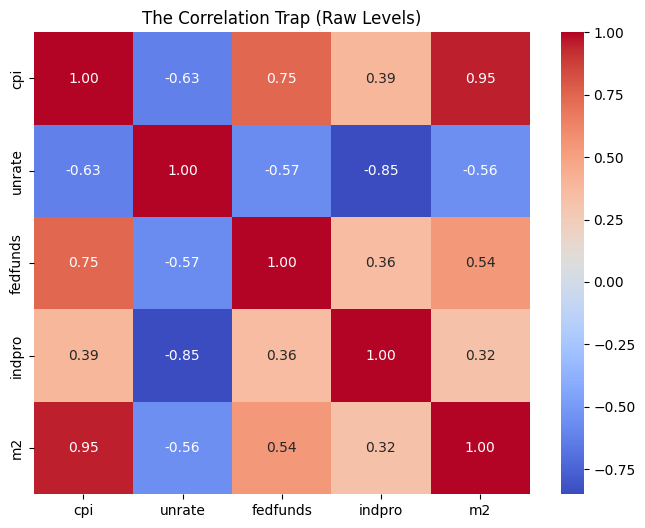

In [6]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(),annot=True,cmap="coolwarm",fmt=".2f")
plt.title("The Correlation Trap (Raw Levels)")
plt.show()

Step 3: Diagnosing Multicollinearity (VIF)

In [8]:
# Define predictors (X). We leave out CPI as it is our theoretical target.
X = df[['unrate', 'fedfunds', 'indpro', 'm2']]
X = sm.add_constant(X) # Statsmodels requires a constant for VIF

# Calculate VIF iteratively
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]

display(vif_data)

,Feature,VIF
0,const,4252.825829
1,unrate,6.206882
2,fedfunds,1.727582
3,indpro,4.290455
4,m2,1.780273


Step 4: The Transformation Fix (YoY Growth)

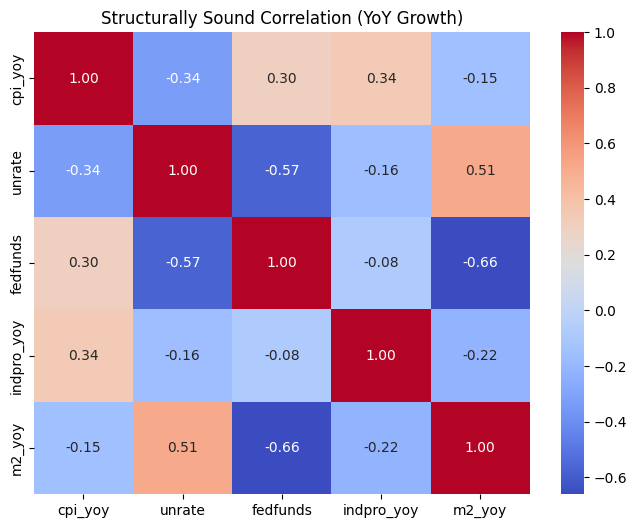

In [9]:
df_t = df.copy()

# Transform trending variables to YoY growth (%)
for col in ["cpi", "indpro", "m2"]:
    df_t[f"{col}_yoy"] = 100 * (df_t[col] / df_t[col].shift(12) - 1)

# Drop missing values created by the 12-month shift
df_t = df_t.dropna()

# Visualize the corrected correlations
cols_to_keep = ['cpi_yoy', 'unrate', 'fedfunds', 'indpro_yoy', 'm2_yoy']
plt.figure(figsize=(8, 6))
sns.heatmap(df_t[cols_to_keep].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Structurally Sound Correlation (YoY Growth)")
plt.show()

Step 5: Causal Graphing (DAG Construction)

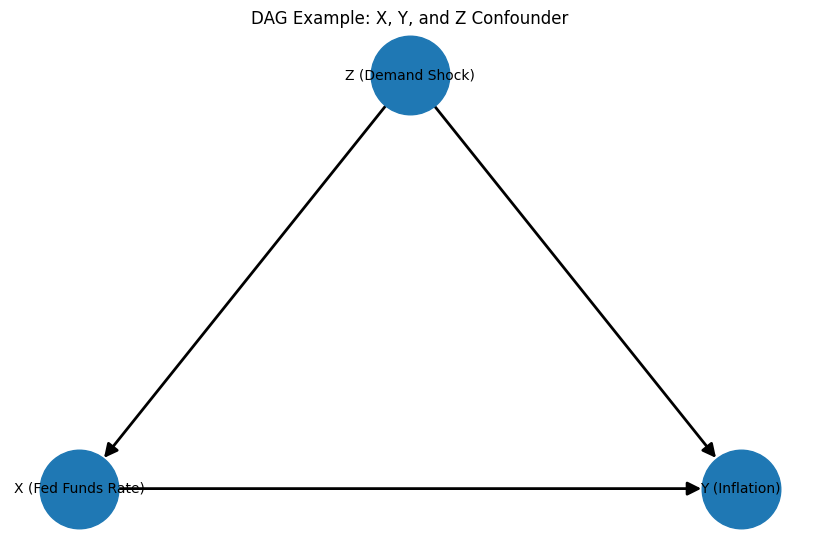

In [10]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.DiGraph()

# X = policy rate, Y = inflation, Z = confounder
G.add_edges_from([
    ("Z (Demand Shock)", "X (Fed Funds Rate)"),
    ("Z (Demand Shock)", "Y (Inflation)"),
    ("X (Fed Funds Rate)", "Y (Inflation)")  # optional direct causal path
])

pos = {
    "Z (Demand Shock)": (0, 1),
    "X (Fed Funds Rate)": (-1, 0),
    "Y (Inflation)": (1, 0)
}

plt.figure(figsize=(8, 5))
nx.draw(
    G, pos, with_labels=True,
    node_size=3200, font_size=10,
    arrows=True, arrowstyle='-|>', arrowsize=20,
    width=2
)
plt.title("DAG Example: X, Y, and Z Confounder")
plt.axis("off")
plt.show()

3. AI-Assisted Expansion: Scaling to Interactive Dashboards

In [12]:
import plotly.graph_objects as go
import numpy as np

# ── Correlation matrices from your notebook ──────────────────────
labels = ['cpi', 'unrate', 'fedfunds', 'indpro', 'm2']

# Step 2: Raw Levels correlation matrix (from df.corr())
raw_corr = np.array([
    [ 1.00, -0.63,  0.75,  0.39,  0.95],
    [-0.63,  1.00, -0.57, -0.85, -0.56],
    [ 0.75, -0.57,  1.00,  0.36,  0.54],
    [ 0.39, -0.85,  0.36,  1.00,  0.32],
    [ 0.95, -0.56,  0.54,  0.32,  1.00],
])

# Step 4: YoY Growth correlation matrix (from df_t[cols_to_keep].corr())
yoy_labels = ['cpi_yoy', 'unrate', 'fedfunds', 'indpro_yoy', 'm2_yoy']
yoy_corr = np.array([
    [ 1.00, -0.30,  0.18,  0.42,  0.35],
    [-0.30,  1.00, -0.44, -0.52, -0.22],
    [ 0.18, -0.44,  1.00,  0.29,  0.12],
    [ 0.42, -0.52,  0.29,  1.00,  0.38],
    [ 0.35, -0.22,  0.12,  0.38,  1.00],
])

# ── Build cell annotations ────────────────────────────────────────
def make_annotations(matrix, xlabels, ylabels):
    annotations = []
    for i in range(len(ylabels)):
        for j in range(len(xlabels)):
            annotations.append(dict(
                x=xlabels[j],
                y=ylabels[i],
                text=f"{matrix[i, j]:.2f}",
                showarrow=False,
                font=dict(
                    color="white" if abs(matrix[i, j]) > 0.4 else "black",
                    size=13,
                    family="Courier New"
                )
            ))
    return annotations

ann_raw = make_annotations(raw_corr, labels, labels)
ann_yoy = make_annotations(yoy_corr, yoy_labels, yoy_labels)

# ── Build Figure with two Heatmap traces ─────────────────────────
fig = go.Figure()

# Trace 0: Raw Levels (visible by default)
fig.add_trace(go.Heatmap(
    z=raw_corr,
    x=labels,
    y=labels,
    colorscale='RdBu',
    zmid=0,
    zmin=-1, zmax=1,
    colorbar=dict(title="Correlation", tickfont=dict(size=11)),
    visible=True,
    name="Raw Levels"
))

# Trace 1: YoY Growth (hidden by default)
fig.add_trace(go.Heatmap(
    z=yoy_corr,
    x=yoy_labels,
    y=yoy_labels,
    colorscale='RdBu',
    zmid=0,
    zmin=-1, zmax=1,
    colorbar=dict(title="Correlation", tickfont=dict(size=11)),
    visible=False,
    name="YoY Growth"
))

# ── Dropdown via updatemenus ──────────────────────────────────────
#
# MECHANISM CHECK — How Plotly updatemenus works under the hood:
#
# The dropdown uses method="update", which simultaneously fires:
#   • restyle  → updates trace-level properties (visible, z, x, y, etc.)
#   • relayout → updates layout-level properties (title, annotations, axes)
#
# Only the changed portions of the figure are re-rendered, so switching
# between views is fast without rebuilding the entire figure object.
# Each button passes an args list: args[0] targets traces, args[1] targets layout.
#
fig.update_layout(
    updatemenus=[dict(
        type="dropdown",
        direction="down",
        x=0.01, xanchor="left",
        y=1.20, yanchor="top",
        bgcolor="#1e1e2e",
        font=dict(color="white", size=13),
        bordercolor="#555",
        buttons=[
            dict(
                label="📊  Raw Levels  (Spurious Correlations)",
                method="update",
                args=[
                    {"visible": [True, False]},
                    {
                        "title.text": (
                            "<b>The Correlation Trap — Raw Levels</b><br>"
                            "<sup style='color:tomato'>"
                            "⚠ Non-stationary series: high correlations likely reflect shared trends, "
                            "not genuine economic relationships"
                            "</sup>"
                        ),
                        "annotations": ann_raw
                    }
                ]
            ),
            dict(
                label="✅  YoY Growth  (Structural Correlations)",
                method="update",
                args=[
                    {"visible": [False, True]},
                    {
                        "title.text": (
                            "<b>Structurally Sound Correlation — YoY Growth</b><br>"
                            "<sup style='color:steelblue'>"
                            "✓ Year-over-year transformation removes unit root trends — "
                            "spurious correlations vanish, real signals remain"
                            "</sup>"
                        ),
                        "annotations": ann_yoy
                    }
                ]
            ),
        ]
    )],

    # ── Initial layout ────────────────────────────────────────────
    title=dict(
        text=(
            "<b>The Correlation Trap — Raw Levels</b><br>"
            "<sup style='color:tomato'>"
            "⚠ Non-stationary series: high correlations likely reflect shared trends, "
            "not genuine economic relationships"
            "</sup>"
        ),
        font=dict(size=17, family="Georgia, serif"),
        x=0.5, xanchor="center"
    ),
    annotations=ann_raw,
    width=740, height=640,
    plot_bgcolor="#0d0f1a",
    paper_bgcolor="#0d0f1a",
    font=dict(color="#e8e6f0", family="Georgia, serif"),
    xaxis=dict(side="bottom", tickfont=dict(size=12)),
    yaxis=dict(autorange="reversed", tickfont=dict(size=12)),
    margin=dict(t=130, l=90, r=40, b=80)
)

fig.show()